In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, log_loss, confusion_matrix, precision_recall_curve, f1_score
import xgboost as xgb
import catboost as cb
import joblib

In [2]:
from sklearn.metrics import auc as calculate_auc

In [25]:
df_cat_val = pd.read_csv('df_cat_val.csv')
df_xgb_val = pd.read_csv('df_xgb_val.csv')

In [26]:
df_cat_val.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,target
0,27,Private,Some-college,Never-married,Other-service,Not-in-family,White,Female,0.0,0.0,34,United-States,<=50K
1,34,Private,Some-college,Separated,Adm-clerical,Unmarried,Black,Female,0.0,0.0,40,Other,<=50K
2,62,Local-gov,9th,Divorced,Protective-serv,Not-in-family,Black,Male,0.0,0.0,24,United-States,<=50K
3,26,Private,HS-grad,Never-married,Craft-repair,Own-child,White,Male,0.0,0.0,35,United-States,<=50K
4,39,Private,10th,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,60,United-States,<=50K


In [27]:
X_cat = df_cat_val.drop('target', axis=1)
y_cat = df_cat_val['target']
X_cat.shape, y_cat.shape

((9769, 12), (9769,))

In [28]:
df_xgb_val.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,target
0,-0.849080,0.210093,-0.031360,0.045961,0.041578,0.103070,0.25586,0.109461,0.0,0.0,-0.521368,0.245835,0
1,-0.335892,0.210093,-0.031360,0.064390,0.134483,0.063262,0.12388,0.109461,0.0,0.0,-0.035429,0.250429,0
2,1.716860,0.294792,-1.974858,0.104209,0.325116,0.103070,0.12388,0.305737,0.0,0.0,-1.331266,0.245835,0
3,-0.922393,0.210093,-0.420060,0.045961,0.226641,0.013220,0.25586,0.305737,0.0,0.0,-0.440378,0.245835,0
4,0.030671,0.210093,-1.586158,0.446848,0.124875,0.448571,0.25586,0.305737,0.0,0.0,1.584366,0.245835,0


In [29]:
X_xgb = df_xgb_val.drop('target', axis=1)
y_xgb = df_xgb_val['target']
X_xgb.shape, y_xgb.shape

((9769, 12), (9769,))

In [30]:
xgb_model = joblib.load('xgb_model.joblib')
cat_model = joblib.load('cat_model.joblib')

In [31]:
y_prob_xgb = xgb_model.predict_proba(X_xgb)[:, 1]
y_prob_cat = cat_model.predict_proba(X_cat)[:, 1]

In [32]:
auc = roc_auc_score(y_xgb, y_prob_xgb)
loss = log_loss(y_xgb, y_prob_xgb)

print(f'XGB Model'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

XGB Model
ROC AUC: 0.9173
Log-Loss: 0.3430


In [33]:
auc = roc_auc_score(y_cat, y_prob_cat)
loss = log_loss(y_cat, y_prob_cat)

print(f'CAT Model'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

CAT Model
ROC AUC: 0.9245
Log-Loss: 0.2863


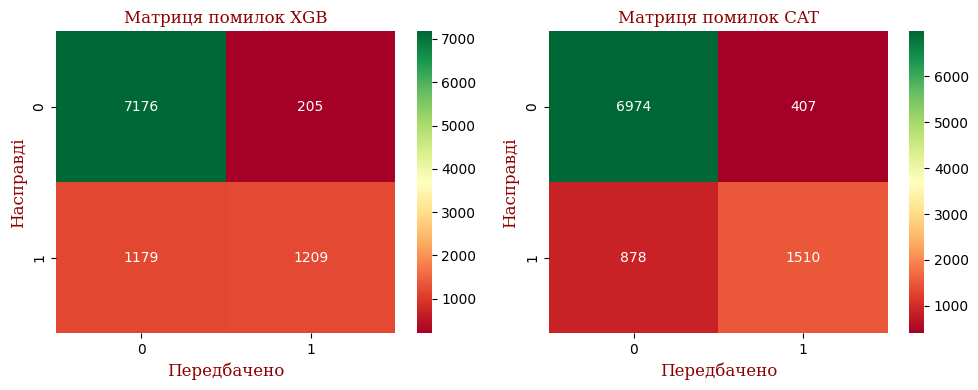

In [34]:
plt.figure(figsize=(10, 4))
myfont = {'family':'serif','color':'darkred','size':12}


plt.subplot(1, 2, 1)

y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

cm = confusion_matrix(y_xgb, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок XGB', fontdict=myfont)


plt.subplot(1, 2, 2)

y_pred_cat = (y_prob_cat > 0.5).astype(int)
y_pred_cat = pd.Series(y_pred_cat).map({0: '<=50K', 1: '>50K'})

cm = confusion_matrix(y_cat, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок CAT', fontdict=myfont)

plt.tight_layout()
plt.show()

In [38]:
thresholds = np.linspace(0.01, 0.99, 100)

y_true_numeric_xgb = (y_xgb == '>50K').astype(int)
y_true_numeric_cat = (y_cat == '>50K').astype(int)

f1_xgb = [f1_score(y_true_numeric_xgb, y_prob_xgb > t, zero_division=0) for t in thresholds]
f1_cat = [f1_score(y_true_numeric_cat, y_prob_cat > t, zero_division=0) for t in thresholds]

best_th_xgb = thresholds[np.argmax(f1_xgb)]
best_th_cat = thresholds[np.argmax(f1_cat)]

In [40]:
print(f'Оптимальні трешхолди для матриці помилок:'
      f'\nXGB: {best_th_xgb}'
      f'\nCAT: {best_th_cat:.3f}')

Оптимальні трешхолди для матриці помилок:
XGB: 0.01
CAT: 0.406


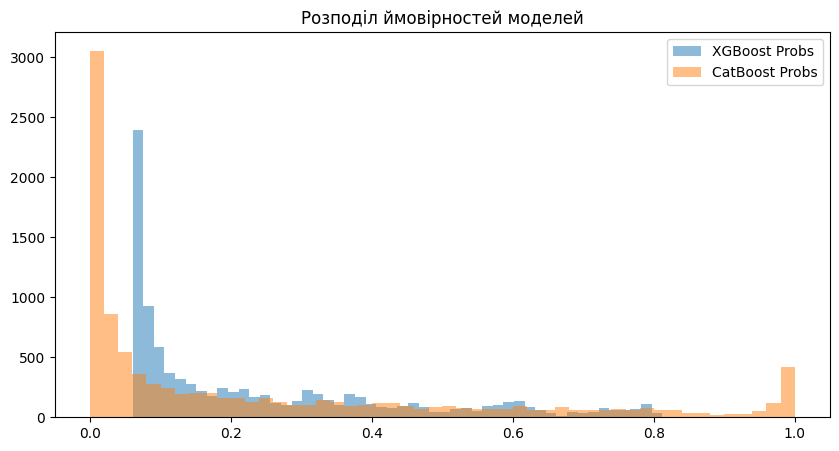

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(y_prob_xgb, bins=50, alpha=0.5, label='XGBoost Probs')
plt.hist(y_prob_cat, bins=50, alpha=0.5, label='CatBoost Probs')
plt.title('Розподіл ймовірностей моделей')
plt.legend()
plt.show()

In [42]:
print(classification_report(y_xgb, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      7381
           1       0.86      0.51      0.64      2388

    accuracy                           0.86      9769
   macro avg       0.86      0.74      0.77      9769
weighted avg       0.86      0.86      0.84      9769



In [43]:
print(classification_report(y_cat, y_pred_cat))

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      7381
        >50K       0.79      0.63      0.70      2388

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.86      0.87      0.86      9769



In [48]:
from xgboost import plot_importance

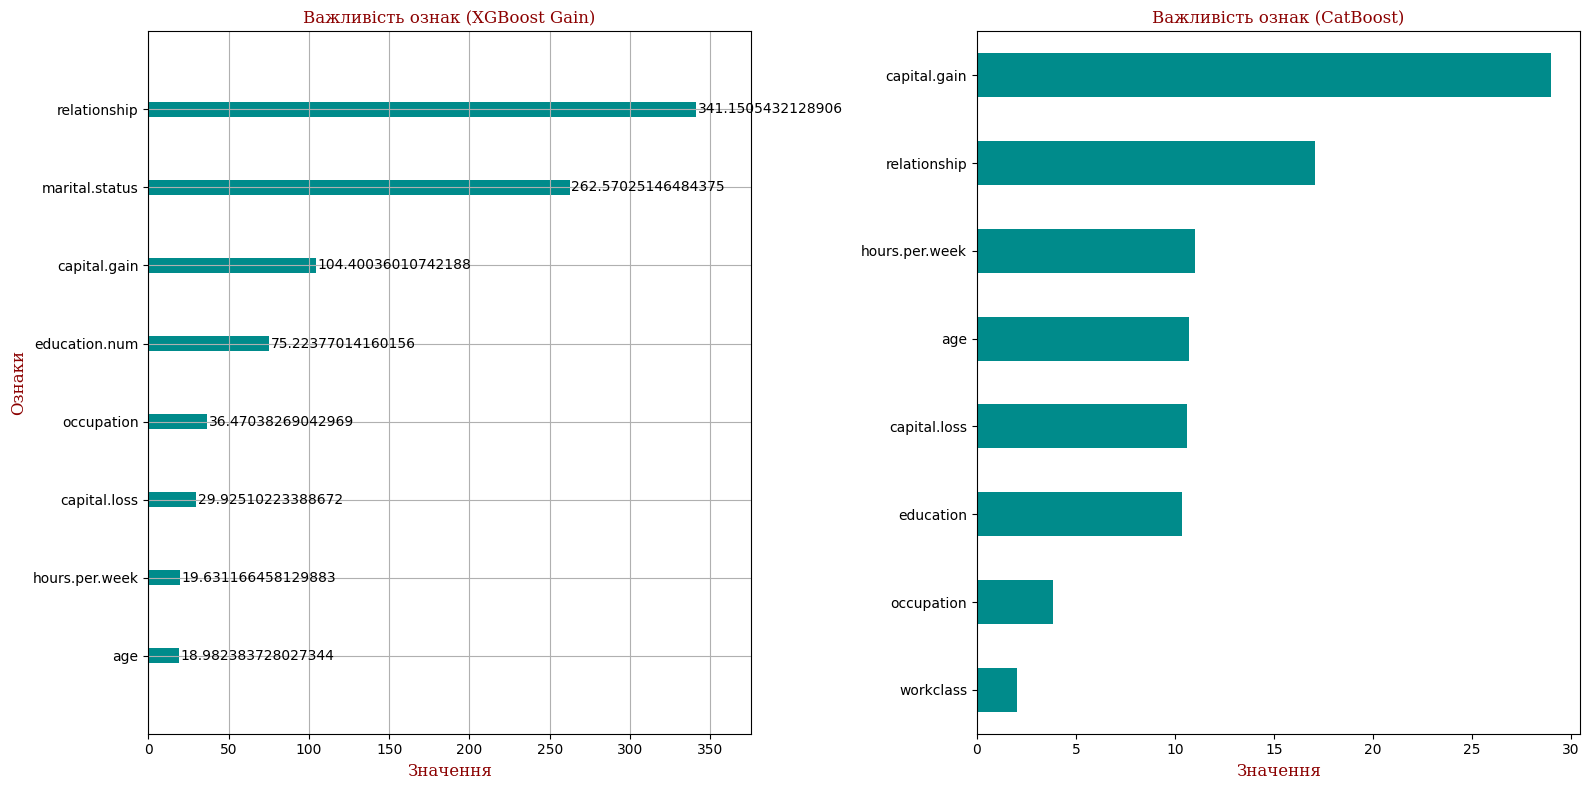

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

plot_importance(xgb_model, importance_type='gain', max_num_features=8, color='DarkCyan', ax=ax1)
ax1.set_title('Важливість ознак (XGBoost Gain)', fontdict=myfont)
ax1.set_xlabel('Значення', fontdict=myfont)
ax1.set_ylabel('Ознаки', fontdict=myfont)

feature_importance = cat_model.get_feature_importance(type='FeatureImportance')
feature_names = X_cat.columns
cat_importances = pd.Series(feature_importance, index=feature_names).sort_values(ascending=True)
top_8_cat = cat_importances.tail(8)
top_8_cat.plot(kind='barh', color='DarkCyan', ax=ax2)
ax2.set_title('Важливість ознак (CatBoost)', fontdict=myfont)
ax2.set_xlabel('Значення', fontdict=myfont)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

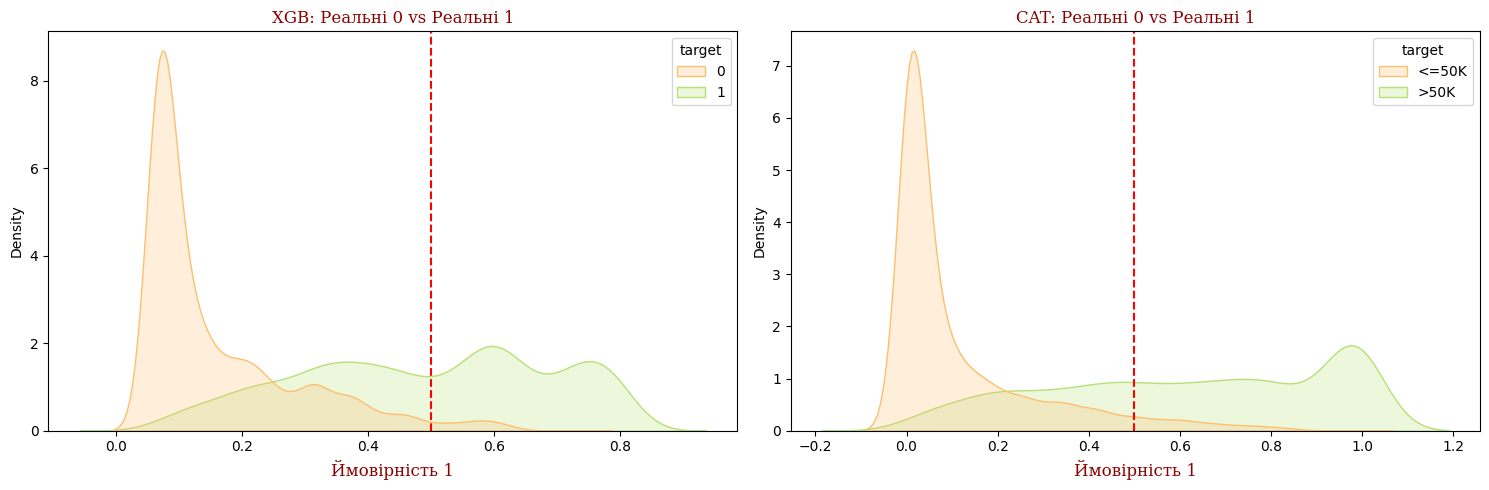

In [51]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(x=y_prob_xgb, hue=y_xgb, fill=True, common_norm=False, palette='RdYlGn')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.title('XGB: Реальні 0 vs Реальні 1', fontdict=myfont)
plt.xlabel('Ймовірність 1', fontdict=myfont)


plt.subplot(1, 2, 2)
sns.kdeplot(x=y_prob_cat, hue=y_cat, fill=True, common_norm=False, palette='RdYlGn')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.title('CAT: Реальні 0 vs Реальні 1', fontdict=myfont)
plt.xlabel('Ймовірність 1', fontdict=myfont)


plt.tight_layout()
plt.show()